In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/PCOS_data.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (465, 16)

Columns:
['Age (in Years)', 'Weight (in Kg)', 'Height (in Cm / Feet)', 'Can you tell us your blood group ?', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'Have you gained weight recently?', 'Do you have excessive body/facial hair growth ?', 'Are you noticing skin darkening recently?', 'Do have hair loss/hair thinning/baldness ?', 'Do you have pimples/acne on your face/jawline ?', 'Do you eat fast food regularly ?', 'Do you exercise on a regular basis ?', 'Have you been diagnosed with PCOS/PCOD?', 'Do you experience mood swings ?', 'Are your periods regular ?', 'How long does your period last ? (in Days)\nexample- 1,2,3,4.....']


,Age (in Years),Weight (in Kg),Height (in Cm / Feet),Can you tell us your blood group ?,After how many months do you get your periods?\n(select 1- if every month/regular),Have you gained weight recently?,Do you have excessive body/facial hair growth ?,Are you noticing skin darkening recently?,Do have hair loss/hair thinning/baldness ?,Do you have pimples/acne on your face/jawline ?,Do you eat fast food regularly ?,Do you exercise on a regular basis ?,Have you been diagnosed with PCOS/PCOD?,Do you experience mood swings ?,Are your periods regular ?,"How long does your period last ? (in Days)\nexample- 1,2,3,4....."
0,21,47.0,168.0,13,1,0,0,0,0,0,0,0,0,1,1,6
1,21,45.0,156.0,11,1,0,0,1,1,1,0,0,0,1,1,4
2,17,37.0,162.0,15,1,0,0,0,0,1,1,0,0,1,1,6
3,28,54.0,160.0,15,1,0,0,0,0,0,0,0,0,1,1,4
4,45,40.0,150.0,13,2,0,0,0,1,0,0,0,1,1,0,7


In [2]:
print(df.columns.tolist())
print(df['Have you been diagnosed with PCOS/PCOD?'].value_counts())


['Age (in Years)', 'Weight (in Kg)', 'Height (in Cm / Feet)', 'Can you tell us your blood group ?', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'Have you gained weight recently?', 'Do you have excessive body/facial hair growth ?', 'Are you noticing skin darkening recently?', 'Do have hair loss/hair thinning/baldness ?', 'Do you have pimples/acne on your face/jawline ?', 'Do you eat fast food regularly ?', 'Do you exercise on a regular basis ?', 'Have you been diagnosed with PCOS/PCOD?', 'Do you experience mood swings ?', 'Are your periods regular ?', 'How long does your period last ? (in Days)\nexample- 1,2,3,4.....']
Have you been diagnosed with PCOS/PCOD?
0    363
1    102
Name: count, dtype: int64


In [3]:
# Rename target column to something shorter
df = df.rename(columns={'Have you been diagnosed with PCOS/PCOD?': 'PCOS'})
df = df.rename(columns={'Have you gained weight recently?': 'Recent Weight Gain'})
df = df.rename(columns={'Can you tell us your blood group ?': 'Blood Group'})
df = df.rename(columns={'Do you exercise on a regular basis ?': 'Regular Excersize'})
df = df.rename(columns={'Do you experience mood swings ?': 'Mood Swings'})
df = df.rename(columns={'Are your periods regular ?': 'Regular Periods'})
df = df.rename(columns={'Do you eat fast food regularly ?': 'Regular Fast Food'})
df = df.rename(columns={'Do you have pimples/acne on your face/jawline ?': 'Jaw/Face Acne/Pimples'})
df = df.rename(columns={'Do you have excessive body/facial hair growth ?': 'Excessive Hair Growth (Body/Facial)'})
df = df.rename(columns={'Do have hair loss/hair thinning/baldness ?': 'Hair Thinning/Baldness'})

# Check data types
print(df.dtypes)


Age (in Years)                                                                          int64
Weight (in Kg)                                                                        float64
Height (in Cm / Feet)                                                                 float64
Blood Group                                                                             int64
After how many months do you get your periods?\n(select 1- if every month/regular)      int64
Recent Weight Gain                                                                      int64
Excessive Hair Growth (Body/Facial)                                                     int64
Are you noticing skin darkening recently?                                               int64
Hair Thinning/Baldness                                                                  int64
Jaw/Face Acne/Pimples                                                                   int64
Regular Fast Food                                           

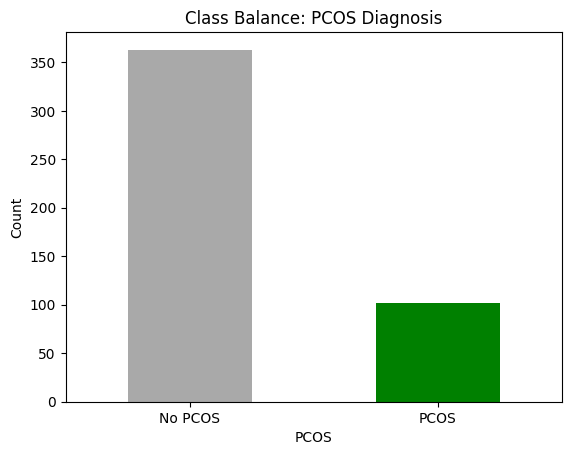

In [4]:
# Plot class balance
df['PCOS'].value_counts().plot(kind='bar', color=['darkgrey', 'green'])
plt.title('Class Balance: PCOS Diagnosis')
plt.xticks([0, 1], ['No PCOS', 'PCOS'], rotation=0)
plt.ylabel('Count')
plt.show()


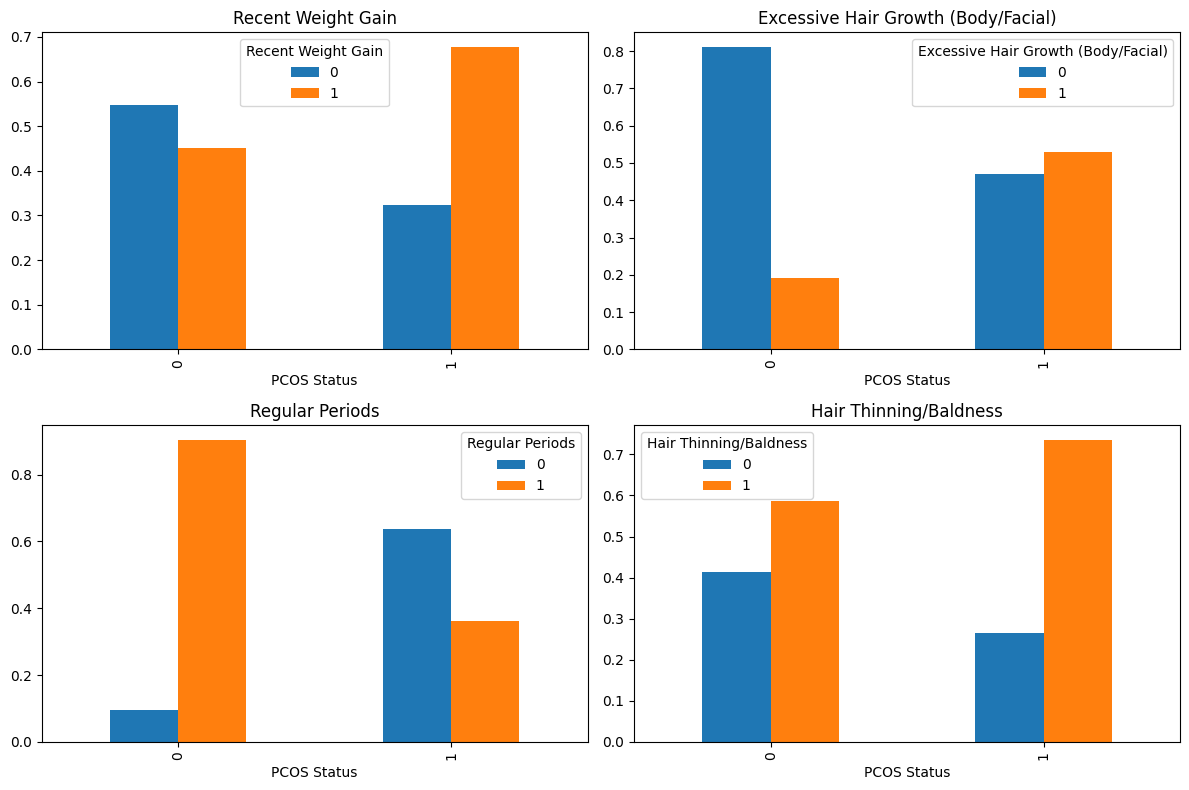

In [5]:
symptom_cols = ['Recent Weight Gain',
                'Excessive Hair Growth (Body/Facial)',
                'Regular Periods',
                'Hair Thinning/Baldness']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), symptom_cols):
    df.groupby('PCOS')[col].value_counts(normalize=True).unstack().plot(kind='bar', ax=ax)
    ax.set_title(col[:40])
    ax.set_xlabel('PCOS Status')
plt.tight_layout()
plt.show()


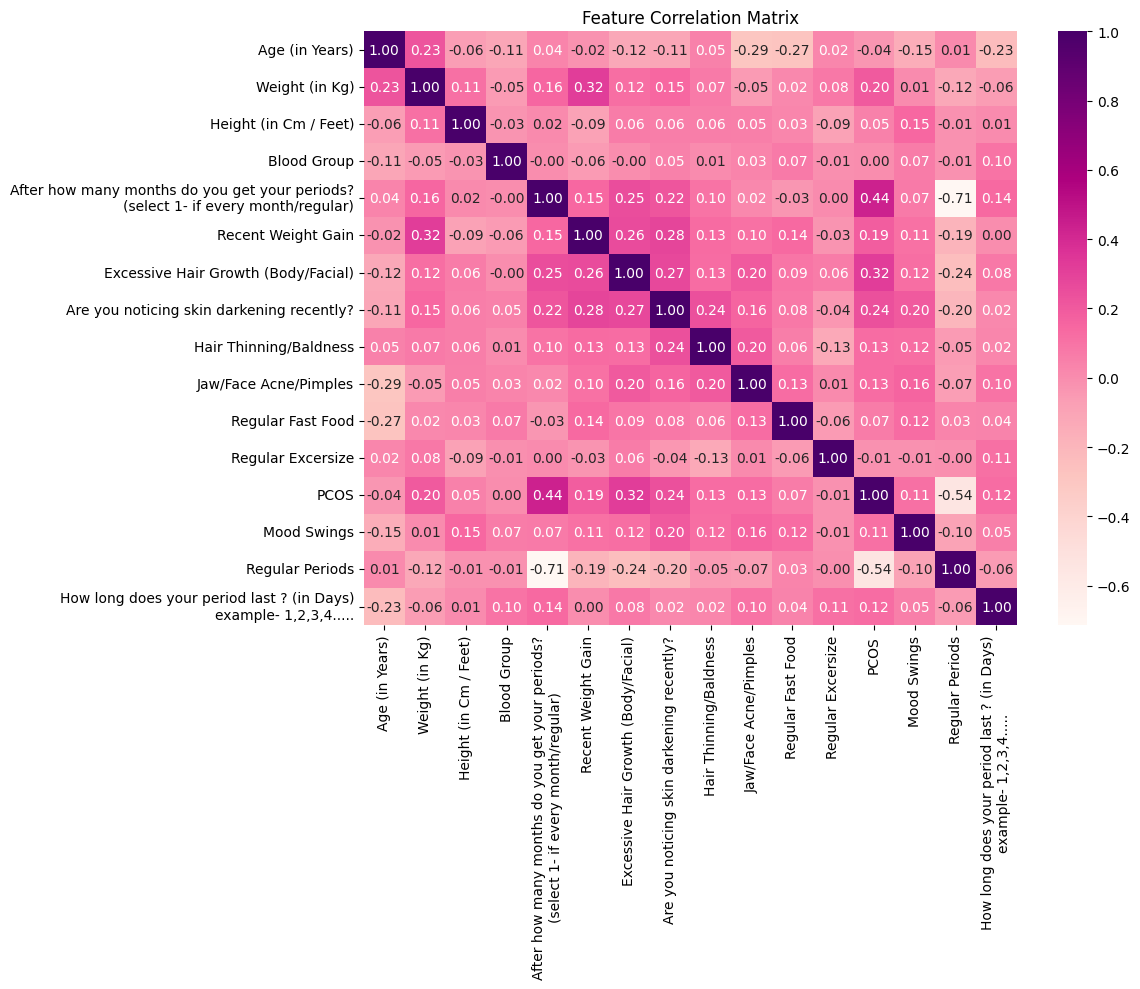

In [6]:
# Correlation heatmap
# All columns are already numeric (see dtypes above) - no encoding needed.
# (pd.factorize() on an already-numeric 0/1 column reorders codes by
# first-appearance, which silently flips the correlation sign - avoid it here.)
df_encoded = df
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="RdPu")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()
# Look for which features correlate most with PCOS column


In [7]:
corr_A = df_encoded.corr()
print(corr_A['PCOS'].sort_values(ascending=False))

PCOS                                                                                  1.000000
After how many months do you get your periods?\n(select 1- if every month/regular)    0.436040
Excessive Hair Growth (Body/Facial)                                                   0.318353
Are you noticing skin darkening recently?                                             0.236946
Weight (in Kg)                                                                        0.196552
Recent Weight Gain                                                                    0.185950
Hair Thinning/Baldness                                                                0.126575
Jaw/Face Acne/Pimples                                                                 0.125437
How long does your period last ? (in Days)\nexample- 1,2,3,4.....                     0.124593
Mood Swings                                                                           0.113965
Regular Fast Food                                 

In [8]:
# inspecting secondary dataset

df_second = pd.read_csv('../data/PCOS_data_second.csv')
print(df_second.shape)
print(df_second.columns.tolist())

(541, 45)
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']


In [9]:
# Drop junk columns
df_second = df_second.drop(columns=['Sl. No', 'Patient File No.', 'Unnamed: 44'])

# Rename target to match your convention
df_second = df_second.rename(columns={'PCOS (Y/N)': 'PCOS'})

# Check class balance
print(df_second['PCOS'].value_counts())

# Check missing values
print(df_second.isnull().sum().sort_values(ascending=False).head(10))

PCOS
0    364
1    177
Name: count, dtype: int64
Marraige Status (Yrs)    1
Fast food (Y/N)          1
PCOS                     0
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
dtype: int64


In [10]:
df_second = df_second.dropna(subset=['Marraige Status (Yrs)', 'Fast food (Y/N)'])
print(f'Secondary rows after cleaning: {len(df_second)}')  # should be 539

Secondary rows after cleaning: 539


In [11]:
# Model A: symptom-only columns (mirrors what patient enters in your app)
symptom_cols = [
    ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI',
    'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
    'Reg.Exercise(Y/N)', 'Cycle(R/I)', 'Cycle length(days)'
]

# Model B: symptom + clinical (what a clinician version would use)
clinical_cols = symptom_cols + [
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
    'TSH (mIU/L)', 'PRL(ng/mL)', 'Waist:Hip Ratio',
    'Follicle No. (L)', 'Follicle No. (R)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)'
]

X_symptom = df_second[symptom_cols]
X_clinical = df_second[clinical_cols]
y = df_second['PCOS']

print(f'Symptom features: {len(symptom_cols)}')
print(f'Clinical features: {len(clinical_cols)}')

Symptom features: 13
Clinical features: 24


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if mood swings issue exists here too (it shouldn't - Kerala doesn't have it)
# Instead check your overlapping symptom correlations
corr_B_symptom_only = df_second[symptom_cols + ['PCOS']].apply(pd.to_numeric, errors='coerce').corr()
print(corr_B_symptom_only['PCOS'].sort_values(ascending=False))

PCOS                    1.000000
Skin darkening (Y/N)    0.481768
hair growth(Y/N)        0.466930
Weight gain(Y/N)        0.443652
Cycle(R/I)              0.402312
Fast food (Y/N)         0.381772
Pimples(Y/N)            0.288609
Weight (Kg)             0.210280
BMI                     0.196479
Hair loss(Y/N)          0.177458
Reg.Exercise(Y/N)       0.069481
Height(Cm)              0.066361
 Age (yrs)             -0.172436
Cycle length(days)     -0.183781
Name: PCOS, dtype: float64


In [13]:
# ── MODEL A: Patient-facing, symptom-only ──

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

symptom_cols_A = [
    'Age (in Years)',
    'Weight (in Kg)',
    'Height (in Cm / Feet)',
    'Blood Group',
    'After how many months do you get your periods?\n(select 1- if every month/regular)',
    'Recent Weight Gain',
    'Excessive Hair Growth (Body/Facial)',
    'Are you noticing skin darkening recently?',
    'Hair Thinning/Baldness',
    'Jaw/Face Acne/Pimples',
    'Regular Fast Food',
    'Regular Excersize',
    'Mood Swings',
    'Regular Periods',
    'How long does your period last ? (in Days)\nexample- 1,2,3,4.....'
]

X_A = df[symptom_cols_A]
y_A = df['PCOS']

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A)

sm_A = SMOTE(random_state=42)
X_train_A_res, y_train_A_res = sm_A.fit_resample(X_train_A, y_train_A)

xgb_A = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_A.fit(X_train_A_res, y_train_A_res)

print("=== Model A: Symptom Only (2023 dataset) ===")
print(classification_report(y_test_A, xgb_A.predict(X_test_A),
      target_names=['No PCOS', 'PCOS']))
print(f'AUC-ROC: {roc_auc_score(y_test_A, xgb_A.predict_proba(X_test_A)[:,1]):.3f}')

=== Model A: Symptom Only (2023 dataset) ===
              precision    recall  f1-score   support

     No PCOS       0.85      0.90      0.87        73
        PCOS       0.53      0.40      0.46        20

    accuracy                           0.80        93
   macro avg       0.69      0.65      0.67        93
weighted avg       0.78      0.80      0.78        93

AUC-ROC: 0.699


/Users/sanjnasood/Documents/GitHub/pcos-screening-tool/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## Feature Selection — Model A (Symptom Only, 2023 dataset)

Beyond the correlation-to-target numbers above, check tree-based feature importance (does XGBoost actually use the feature to split) and VIF (is the feature redundant with other features).

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Tree-based importance from the already-fitted Model A
importance_A = pd.Series(xgb_A.feature_importances_, index=symptom_cols_A) \
    .sort_values(ascending=False)

# VIF (with an intercept column, otherwise features far from zero-mean get
# artificially inflated VIF)
X_A_const = add_constant(X_A)
vif_A = pd.DataFrame({
    'feature': X_A_const.columns,
    'VIF': [variance_inflation_factor(X_A_const.values, i) for i in range(X_A_const.shape[1])]
})
vif_A = vif_A[vif_A['feature'] != 'const'].set_index('feature')['VIF']

selection_A = pd.DataFrame({
    'abs_corr': corr_A['PCOS'].abs().reindex(symptom_cols_A),
    'tree_importance': importance_A,
    'VIF': vif_A,
}).sort_values('abs_corr', ascending=False)

selection_A

,abs_corr,tree_importance,VIF
Regular Periods,0.544719,0.625309,2.120483
After how many months do you get your periods?\n(select 1- if every month/regular),0.436040,0.012831,2.184672
Excessive Hair Growth (Body/Facial),0.318353,0.025936,1.225366
Are you noticing skin darkening recently?,0.236946,0.026141,1.260967
Weight (in Kg),0.196552,0.025582,1.263158
Recent Weight Gain,0.185950,0.012129,1.315227
Hair Thinning/Baldness,0.126575,0.039082,1.152675
Jaw/Face Acne/Pimples,0.125437,0.026050,1.197144
"How long does your period last ? (in Days)\nexample- 1,2,3,4.....",0.124593,0.033853,1.118277
Mood Swings,0.113965,0.028417,1.110316


In [15]:
print(df.columns.tolist())


['Age (in Years)', 'Weight (in Kg)', 'Height (in Cm / Feet)', 'Blood Group', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'Recent Weight Gain', 'Excessive Hair Growth (Body/Facial)', 'Are you noticing skin darkening recently?', 'Hair Thinning/Baldness', 'Jaw/Face Acne/Pimples', 'Regular Fast Food', 'Regular Excersize', 'PCOS', 'Mood Swings', 'Regular Periods', 'How long does your period last ? (in Days)\nexample- 1,2,3,4.....']


In [16]:
# ── MODEL B: Symptom + Clinical (Kerala dataset) ──

symptom_cols_B = [
    ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI',
    'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
    'Reg.Exercise(Y/N)', 'Cycle(R/I)', 'Cycle length(days)'
]

clinical_cols_B = symptom_cols_B + [
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
    'TSH (mIU/L)', 'PRL(ng/mL)', 'Waist:Hip Ratio',
    'Follicle No. (L)', 'Follicle No. (R)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)'
]

# BMI, FSH/LH and Waist:Hip Ratio were Excel formula columns that broke on
# import (`#NAME?` in most rows) - recompute them directly from their raw
# components instead of trusting the broken column.
df_second['BMI'] = df_second['Weight (Kg)'] / (df_second['Height(Cm) '] / 100) ** 2
df_second['FSH/LH'] = (
    pd.to_numeric(df_second['FSH(mIU/mL)'], errors='coerce')
    / pd.to_numeric(df_second['LH(mIU/mL)'], errors='coerce')
)
df_second['Waist:Hip Ratio'] = (
    pd.to_numeric(df_second['Waist(inch)'], errors='coerce')
    / pd.to_numeric(df_second['Hip(inch)'], errors='coerce')
)

# Remaining clinical columns are numeric but stored as text; coerce them all,
# then check what's left over
for col in clinical_cols_B:
    df_second[col] = pd.to_numeric(df_second[col], errors='coerce')

na_counts = df_second[clinical_cols_B].isna().sum()
print("Remaining missing values after coercion:")
print(na_counts[na_counts > 0])

# Only AMH(ng/mL) has a genuine bad entry (a single 'a' value) - median impute it
df_second['AMH(ng/mL)'] = df_second['AMH(ng/mL)'].fillna(df_second['AMH(ng/mL)'].median())

X_B = df_second[clinical_cols_B]
y_B = df_second['PCOS']

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B)

sm_B = SMOTE(random_state=42)
X_train_B_res, y_train_B_res = sm_B.fit_resample(X_train_B, y_train_B)

xgb_B = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_B.fit(X_train_B_res, y_train_B_res)

print("\n=== Model B: Symptom + Clinical (Kerala dataset) ===")
print(classification_report(y_test_B, xgb_B.predict(X_test_B),
      target_names=['No PCOS', 'PCOS']))
print(f'AUC-ROC: {roc_auc_score(y_test_B, xgb_B.predict_proba(X_test_B)[:,1]):.3f}')

Remaining missing values after coercion:
AMH(ng/mL)    1
dtype: int64


/Users/sanjnasood/Documents/GitHub/pcos-screening-tool/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



=== Model B: Symptom + Clinical (Kerala dataset) ===
              precision    recall  f1-score   support

     No PCOS       0.93      0.89      0.91        73
        PCOS       0.79      0.86      0.82        35

    accuracy                           0.88       108
   macro avg       0.86      0.87      0.87       108
weighted avg       0.88      0.88      0.88       108

AUC-ROC: 0.918


## Feature Selection — Model B (Symptom + Clinical, Kerala dataset)

Same three-way check: correlation to target (already computed for the symptom-only subset earlier), tree importance, and VIF across the full clinical feature set.

In [17]:
# Correlation to target across the full clinical feature set (not just symptom_cols_B)
corr_B = df_second[clinical_cols_B + ['PCOS']].corr()['PCOS'].drop('PCOS')

# Tree-based importance from the already-fitted Model B
importance_B = pd.Series(xgb_B.feature_importances_, index=clinical_cols_B) \
    .sort_values(ascending=False)

# VIF (with intercept, same reasoning as Model A)
X_B_const = add_constant(X_B)
vif_B = pd.DataFrame({
    'feature': X_B_const.columns,
    'VIF': [variance_inflation_factor(X_B_const.values, i) for i in range(X_B_const.shape[1])]
})
vif_B = vif_B[vif_B['feature'] != 'const'].set_index('feature')['VIF']

selection_B = pd.DataFrame({
    'abs_corr': corr_B.abs(),
    'tree_importance': importance_B,
    'VIF': vif_B,
}).sort_values('abs_corr', ascending=False)

selection_B

,abs_corr,tree_importance,VIF
Follicle No. (R),0.651032,0.270931,3.191979
Follicle No. (L),0.601445,0.065159,3.255503
Skin darkening (Y/N),0.481768,0.061847,1.409312
hair growth(Y/N),0.466930,0.061404,1.343590
Weight gain(Y/N),0.443652,0.043146,1.649903
Cycle(R/I),0.402312,0.091298,1.277912
Fast food (Y/N),0.381772,0.059678,1.389334
Pimples(Y/N),0.288609,0.025383,1.233032
AMH(ng/mL),0.264251,0.018016,1.170200
Weight (Kg),0.210280,0.016534,217.961527


## Final Feature Selection

Rule: keep a feature if `|correlation with PCOS| >= 0.10`. This is a low bar on purpose — it's mainly there to drop pure noise columns (e.g. Blood Group, which is a garbled multi-choice field, not real blood group data) rather than to aggressively prune. Tree importance and VIF are then used as a **check** on top of that rule, not a second filter:

- Model A: no VIF issues (`Height`/`Weight`/`Blood Group` looked high without an intercept term, but that was a mean-centering artifact — with `add_constant`, all VIFs are under 2.2).
- Model B: `Weight`/`Height`/`BMI` are collinear by construction (BMI is a deterministic function of the other two), and same for `FSH`/`LH`/`FSH/LH`. The correlation threshold already drops `Height`, `LH`, `FSH`, and `FSH/LH` on its own signal — but `Weight` and `BMI` both clear 0.10, so `Weight` is dropped explicitly in favor of `BMI` (the standard clinical composite) to resolve the remaining VIF ~5.6.

In [18]:
CORR_THRESHOLD = 0.10

FINAL_FEATURES_A = selection_A[selection_A['abs_corr'] >= CORR_THRESHOLD].index.tolist()
FINAL_FEATURES_B = selection_B[selection_B['abs_corr'] >= CORR_THRESHOLD].index.tolist()

# Weight and BMI both clear the threshold but are collinear (BMI is derived
# from Weight and Height) - keep BMI, the standard clinical composite
FINAL_FEATURES_B = [f for f in FINAL_FEATURES_B if f != 'Weight (Kg)']

print(f'Model A: {len(FINAL_FEATURES_A)}/{len(symptom_cols_A)} features kept')
print(FINAL_FEATURES_A)
print(f'\nModel B: {len(FINAL_FEATURES_B)}/{len(clinical_cols_B)} features kept')
print(FINAL_FEATURES_B)

# Confirm the VIF issue is actually resolved for Model B's final set
X_B_final_const = add_constant(df_second[FINAL_FEATURES_B])
vif_B_final = pd.Series(
    [variance_inflation_factor(X_B_final_const.values, i) for i in range(X_B_final_const.shape[1])],
    index=X_B_final_const.columns
).drop('const').sort_values(ascending=False)
print('\nModel B final VIF (max):', vif_B_final.max().round(2))

Model A: 10/15 features kept
['Regular Periods', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'Excessive Hair Growth (Body/Facial)', 'Are you noticing skin darkening recently?', 'Weight (in Kg)', 'Recent Weight Gain', 'Hair Thinning/Baldness', 'Jaw/Face Acne/Pimples', 'How long does your period last ? (in Days)\nexample- 1,2,3,4.....', 'Mood Swings']

Model B: 14/24 features kept
['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Fast food (Y/N)', 'Pimples(Y/N)', 'AMH(ng/mL)', 'BMI', 'Cycle length(days)', 'Hair loss(Y/N)', ' Age (yrs)', 'Avg. F size (L) (mm)']

Model B final VIF (max): 3.15


## Cross-Dataset Overlap Check

The two datasets don't share a schema, but several symptom questions are asking the same thing under different column names. Where a feature exists in both, compare its selection status and correlation sign/magnitude as a sanity check — if the same underlying symptom shows up as predictive in both independently-collected datasets, that's stronger evidence than either alone.

In [19]:
# Map same-concept columns across the two datasets (name, not schema, differs)
overlap_map = {
    'Age (in Years)':                              ' Age (yrs)',
    'Weight (in Kg)':                               'Weight (Kg)',
    'Height (in Cm / Feet)':                        'Height(Cm) ',
    'Recent Weight Gain':                           'Weight gain(Y/N)',
    'Excessive Hair Growth (Body/Facial)':          'hair growth(Y/N)',
    'Are you noticing skin darkening recently?':    'Skin darkening (Y/N)',
    'Hair Thinning/Baldness':                       'Hair loss(Y/N)',
    'Jaw/Face Acne/Pimples':                        'Pimples(Y/N)',
    'Regular Fast Food':                             'Fast food (Y/N)',
    'Regular Excersize':                            'Reg.Exercise(Y/N)',
    'Regular Periods':                              'Cycle(R/I)',
}

overlap = pd.DataFrame([
    {
        'feature_A (2023 dataset)': a,
        'feature_B (Kerala dataset)': b,
        'corr_A': corr_A['PCOS'][a],
        'corr_B': corr_B[b],
        'in_FINAL_A': a in FINAL_FEATURES_A,
        'in_FINAL_B': b in FINAL_FEATURES_B,
    }
    for a, b in overlap_map.items()
])
overlap

,feature_A (2023 dataset),feature_B (Kerala dataset),corr_A,corr_B,in_FINAL_A,in_FINAL_B
0,Age (in Years),Age (yrs),-0.037577,-0.172436,False,True
1,Weight (in Kg),Weight (Kg),0.196552,0.210280,True,False
2,Height (in Cm / Feet),Height(Cm),0.045123,0.066361,False,False
3,Recent Weight Gain,Weight gain(Y/N),0.185950,0.443652,True,True
4,Excessive Hair Growth (Body/Facial),hair growth(Y/N),0.318353,0.466930,True,True
5,Are you noticing skin darkening recently?,Skin darkening (Y/N),0.236946,0.481768,True,True
6,Hair Thinning/Baldness,Hair loss(Y/N),0.126575,0.177458,True,True
7,Jaw/Face Acne/Pimples,Pimples(Y/N),0.125437,0.288609,True,True
8,Regular Fast Food,Fast food (Y/N),0.068979,0.381772,False,True
9,Regular Excersize,Reg.Exercise(Y/N),-0.013503,0.069481,False,False


**Reading the overlap table:**

- `Regular Periods` (A) and `Cycle(R/I)` (B) have opposite-signed correlation, but that's just arbitrary label encoding, not disagreement: in A, `1` = regular / `0` = irregular; in B, the cycle code for irregular is numerically *higher* than regular. Both datasets agree on the underlying clinical fact — irregular cycles go with more PCOS — and it's the single strongest signal in both.
- Skin darkening, hair growth, weight gain, and pimples/acne all clear `FINAL_FEATURES` in both datasets independently — good cross-validation that these are real signals, not one-dataset artifacts.
- `Age`, raw `Height`, `Regular Excersize`/`Reg.Exercise` and `Regular Fast Food`/`Fast food` are weak-to-noise in **both** datasets, reinforcing that they were correctly dropped rather than dropped due to one dataset's quirks.
- **Not** treated as overlapping: dataset A's "how long does your period last (days)" (bleed duration) vs. dataset B's `Cycle length(days)` (days *between* periods) — similar names, different concepts. Mixing these up would be a mistake, so they're kept out of the `overlap_map`.
- `Blood Group` exists in both datasets by name but isn't in either `FINAL_FEATURES` list (near-zero correlation in both) and dataset A's version looks like a garbled multi-choice field rather than real blood-type data — dropped from both, not compared here.